In [1]:
from torch_snippets import *
from torchvision import transforms as T
from torch.nn import functional as F
from torchvision.models import vgg19
device = 'cuda' if torch.cuda.is_available() else 'cpu' #imports

In [2]:
preprocess = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    T.Lambda(lambda x: x.mul_(255))
]) #converte e normaliza a imagem

postprocess = T.Compose([
    T.Lambda(lambda x: x.mul_(1./255)),
    T.Normalize(mean=[-0.485/0.229, -0.456/0.224,-0.406/0.225], std=[1/0.229,1/0.224,1/0.225]),
]) #sequencia pra recuperar a imagem

In [3]:
class GramMatrix(nn.Module):
    def forward(self,input):
        b,c,h,w = input.size() #pega batch, canais, altura e largura
        feat = input.view(b,c,h*w) 
        G = feat@feat.transpose(1,2) #calcula a matriz gram
        G.div_(h*w) #normaliza
        return G  #e volta a matriz gram
class GramMSELoss(nn.Module):
    def forward(self,input,target):
        out = F.mse_loss(GramMatrix()(input),target) 
        return(out) #pega o erro e retorna
class vgg19_modified(nn.Module): 
    def __init__(self):
        super().__init__()
        features = list(vgg19(pretrained = True).features) #carrega camadas vgg
        self.features = nn.ModuleList(features).eval() #modo de avaliacao
    def forward(self, x, layers=[]): 
        order = np.argsort(layers)
        _results, results = [], [] #listas
        for ix, model in enumerate(self.features):
            x = model(x) #passa a imagem na camada
            if ix in layers: #se for na camada desejada
                _results.append(x) #add
        for o in order:
            results.append(_results[o])

        return results if layers is not [] else x

In [4]:
vgg = vgg19_modified().to(device) #coloca na variavel a classe e manda pra gpu

/home/voraztitan/.local/lib/python3.14/site-packages/torchvision/models/_utils.py:207: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/voraztitan/.local/lib/python3.14/site-packages/torchvision/models/_utils.py:222: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [5]:
!wget https://easydrawingguides.com/wp-content/uploads/2016/10/how-to-draw-an-elephant-featured-image-1200.png
!wget https://www.neh.gov/sites/default/files/2022-09/Fall_2022_web-images_Picasso_32.jpg #baixa imagens



7[Files: 0  Bytes: 0  [0 B/s] Re]87[https://easydrawingguides.com/]87Saving 'how-to-draw-an-elephant-featured-image-1200.png.1'
87how-to-draw-an-eleph 100% [=============================>]   55.60K    --.-KB/s87HTTP response 200  [https://easydrawingguides.com/wp-content/uploads/2016/10/how-to-draw-an-elephant-featured-image-1200.png]
87how-to-draw-an-eleph 100% [=============================>]   55.60K    --.-KB/s87[Files: 1  Bytes: 55.60K [257.4]8

7[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87[https://www.neh.gov/sites/defa]87Saving 'Fall_2022_web-images_Picasso_32.jpg.1'
87Fall_2022_web-images   0% [>                             ]   21.55K    --.-KB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87[Files: 0  Bytes: 0  [0 B/s] Re]87Fall_2022_web-images  23% [======>                       ]    1.20M    1.18MB/s87[Files: 0  Bytes: 0  [0 B/s] Re]87Fall_2022_web-images  56% [===============>              ]    2.84M    1.41MB/s87[Files: 0  

In [7]:
imgs = [Image.open(path).resize((512,512)).convert('RGB') for path in ['Fall_2022_web-images_Picasso_32.jpg','how-to-draw-an-elephant-featured-image-1200.png']]
style_image, content_image = [preprocess(img).to(device)[None] for img in imgs] #carrega a imagem redimensiona e aplica um pre processamento

In [8]:
opt_img = content_image.data.clone() 
opt_img.requires_grad = True #copia a imagem e calcula os gradientes

In [9]:
style_layers = [0, 5, 10, 19, 28]
content_layers = [21]
loss_layers = style_layers + content_layers #junta as camaddas

In [10]:
loss_fns = [GramMSELoss()] * len(style_layers) + [nn.MSELoss()] * len(content_layers) #funcao de perda
loss_fns = [loss_fn.to(device) for loss_fn in loss_fns] #coloca no device

In [11]:
style_weights = [1000/n**2 for n in [64,128,256,512,512]] #pesos da perda
content_weights = [1]
weights = style_weights + content_weights #junta os pesos

In [12]:
style_targets = [GramMatrix()(A).detach() for A in vgg(style_image, style_layers)]
content_targets = [A.detach() for A in vgg(content_image, content_layers)]
targets = style_targets + content_targets #pega as caracteristicas da imagem do estilo, pega o gram e coloca estilo e o conteudo da imagem

In [13]:
max_iters = 500 #interacoes
optimizer = optim.LBFGS([opt_img]) #otimizacao
log = Report(max_iters) #logs

In [14]:
iters = 0 
while iters < max_iters:  #ate as 500
    def closure(): #
        global iters
        iters += 1
        optimizer.zero_grad() #zera os gradientes pra proxima
        out = vgg(opt_img, loss_layers) #pega caracteristicas
        layer_losses = [weights[a] * loss_fns[a](A, targets[a]) for a, A in enumerate(out)] #erro de cada camada
        loss = sum(layer_losses) #soma todos os erros
        loss.backward() 
        log.record(pos = iters, loss = loss, end = '\r') 
        return loss #retorna a perda
    optimizer.step(closure) #atualiza

EPOCH: 502.000  loss: 1295760.000  (76.82s - -0.31s remaining))

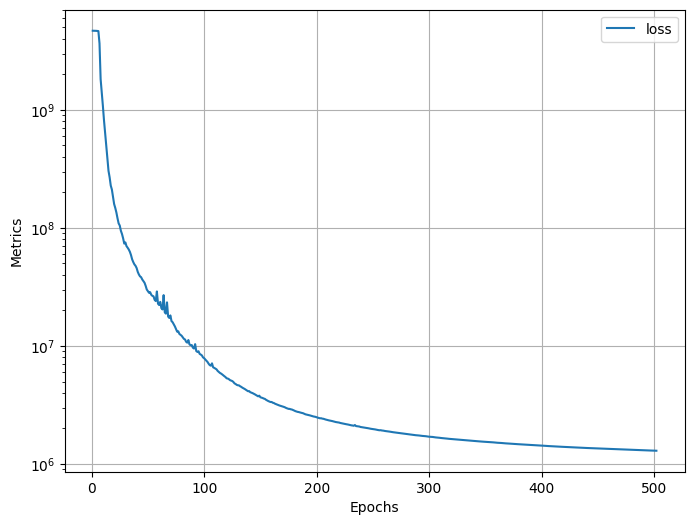

In [15]:
log.plot(log = True) #plotando a log

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9344136..1.5920976].


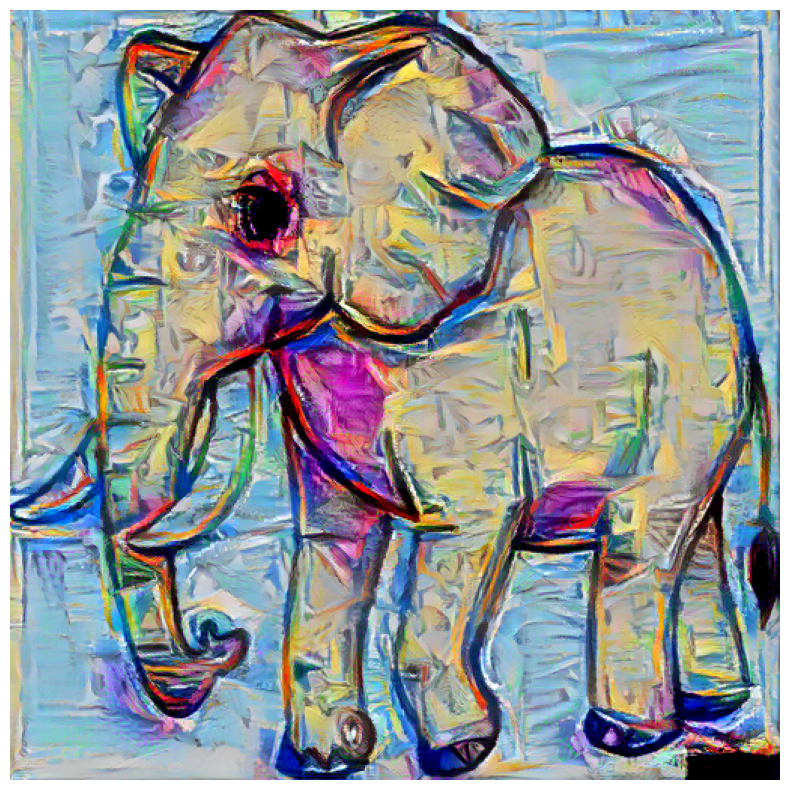

In [16]:
with torch.no_grad():
    out_img = postprocess(opt_img[0]).permute(1,2,0)
show(out_img) #pega a imagem de saida